In [ ]:
# !nvidia-smi

**Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

**Connect Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Load CSV File**

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/Research Projects /Data Science and ML /Code/WQI Calculation Code/New WQI Code for DSML/Output.csv", index_col=False)
data.head()

,WaterbodyName,Years,SampleDate,Alkalinity-total (as CaCO3),Ammonia-Total (as N),BOD - 5 days (Total),Chloride,Conductivity @25°C,Dissolved Oxygen,ortho-Phosphate (as P) - unspecified,...,Total Hardness (as CaCO3),True Colour,IndWQI,IndWQI_Score,IWQI,IWQI_Score,DWQI,DWQI_Score,AWQI,AWQI_Score
0,ABBEYTOWN_010,2023,Feb,314.0,0.033,1.2,27.3,711.0,52.50,0.019,...,370.0,24.0,Poor,42.301154,Very Bad,17.448707,Poor,35.893750,Good,72.102564
1,Allua,2007,Aug,14.0,0.033,1.2,10.0,71.0,61.85,0.019,...,13.4,35.0,Good,78.931487,Average,55.420458,Medium,52.841607,Good,72.102564
2,Allua,2007,Aug,17.0,0.033,1.2,11.5,79.0,61.80,0.019,...,15.8,29.0,Good,78.214201,Bad,51.709486,Medium,52.518036,Good,72.102564
3,Allua,2007,Aug,18.0,0.033,1.2,11.3,78.0,62.40,0.019,...,15.9,31.0,Good,78.192201,Bad,52.073298,Medium,52.538929,Good,72.102564
4,Allua,2007,Sep,19.0,0.033,1.2,10.5,76.0,66.05,0.019,...,15.4,23.0,Good,78.295059,Bad,54.235504,Medium,52.630000,Good,72.102564


**Null Value Check: Though it was confirmed in Data Wragling Phase**

In [ ]:
null_values = data.isnull().sum()
null_values

,0
WaterbodyName,0
Years,0
SampleDate,0
Alkalinity-total (as CaCO3),0
Ammonia-Total (as N),0
BOD - 5 days (Total),0
Chloride,0
Conductivity @25°C,0
Dissolved Oxygen,0
ortho-Phosphate (as P) - unspecified,0


In [ ]:
data = data.dropna()

In [ ]:
null_values = data.isnull().sum()
null_values

DO                0
Ammonia           0
Hardness          0
Temp              0
Alkalinity        0
Conductivity      0
BOD               0
Color             0
orthophosphate    0
pH                0
CCME_WQI          0
CCME_WQI_Score    0
WAWQI_Values      0
WAWQI_Quality     0
IndWQI            0
IndWQI_Score      0
IWQI              0
IWQI_Score        0
DWQI              0
DWQI_Score        0
AWQI              0
AWQI_Score        0
RWQI              0
RWQI_Score        0
dtype: int64

In [ ]:
data.shape

(29159, 22)

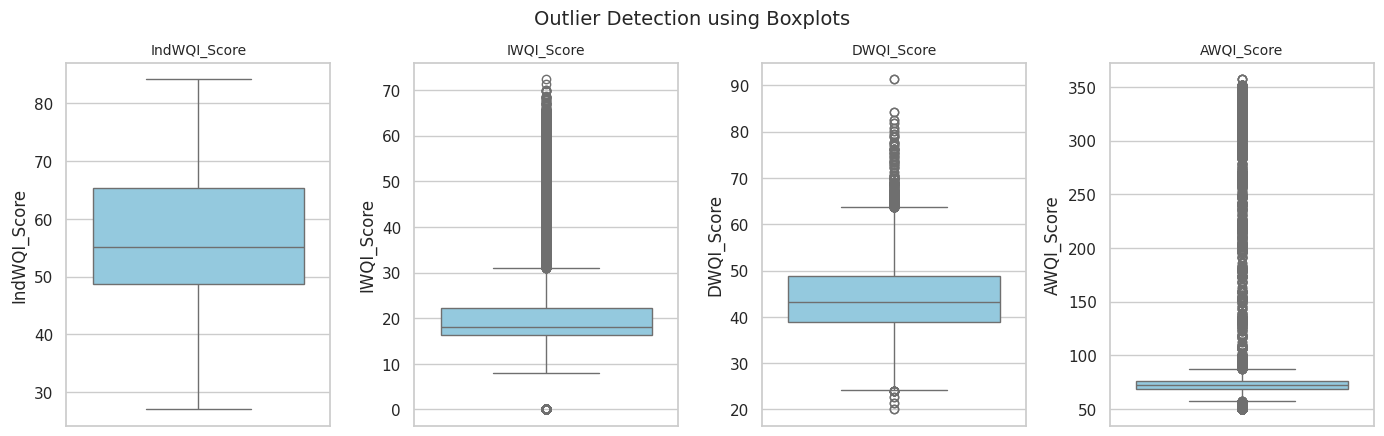

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of columns to check for outliers
columns = ['IndWQI_Score',
           'IWQI_Score', 'DWQI_Score', 'AWQI_Score']

# Set plot style
sns.set(style="whitegrid")
plt.figure(figsize=(14, 8))

# Create boxplots for each column
for i, col in enumerate(columns, 1):
    plt.subplot(2, 4, i)  # Adjust the layout: 2 rows, 4 columns
    sns.boxplot(y=data[col], color="skyblue")
    plt.title(col, fontsize=10)
    plt.tight_layout()

plt.suptitle("Outlier Detection using Boxplots", fontsize=14, y=1.02)
plt.show()

In [ ]:
# List of columns to check for outliers
columns = ['CCME_WQI_Score', 'WAWQI_Values', 'IndWQI_Score',
           'IWQI_Score', 'DWQI_Score', 'AWQI_Score', 'RWQI_Score']

# Make a copy to preserve original
data_cleaned = data.copy()

# Loop through each column to remove outliers
for col in columns:
    Q1 = data_cleaned[col].quantile(0.25)
    Q3 = data_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out the outliers
    data_cleaned = data_cleaned[(data_cleaned[col] >= lower_bound) & (data_cleaned[col] <= upper_bound)]

# Check the shape before and after
print(f"Original data shape: {data.shape}")
print(f"Cleaned data shape: {data_cleaned.shape}")

In [ ]:
data = data.rename(columns={
    'Dissolved Oxygen': 'DO',
    'Ammonia-Total (as N)': 'Ammonia',
    'Total Hardness (as CaCO3)': 'Hardness',
    'Temperature': 'Temp',
    'Alkalinity-total (as CaCO3)': 'Alkalinity',
    'Conductivity @25°C': 'Conductivity',
    'BOD - 5 days (Total)': 'BOD',
    'True Colour': 'Color',
    'ortho-Phosphate (as P) - unspecified': 'orthophosphate',
    'pH': 'pH'  # stays the same but included for completeness
})

In [ ]:
# Define the input features and output variables
input_features = [
    'Alkalinity', 'Ammonia', 'BOD',
       'Chloride', 'Conductivity', 'DO', 'orthophosphate', 'pH', 'Temp',
       'Hardness', 'Color' ]

Reg_output = ['IndWQI_Score','IWQI_Score','DWQI_Score', 'AWQI_Score']
# Class_output= ["CCME_WQI", "WAWQI_Quality", "IndWQI", "IWQI", "DWQI", "AWQI", "RWQI"]

In [ ]:
# Separate input and output variables
X = data[input_features]
y_reg = data[Reg_output]
# y_class = data[Class_output]

In [ ]:
y_reg = y_reg['AWQI_Score']

In [ ]:
y_reg

,AWQI_Score
0,72.102564
1,72.102564
2,72.102564
3,72.102564
4,72.102564
...,...
29154,60.000000
29155,56.000000
29156,50.000000
29157,70.102564


In [ ]:
X.head()

,Alkalinity,Ammonia,BOD,Chloride,Conductivity,DO,orthophosphate,pH,Temp,Hardness,Color
0,314.0,0.033,1.2,27.3,711.0,52.50,0.019,7.80,10.4,370.0,24.0
1,14.0,0.033,1.2,10.0,71.0,61.85,0.019,7.42,17.8,13.4,35.0
2,17.0,0.033,1.2,11.5,79.0,61.80,0.019,7.67,18.1,15.8,29.0
3,18.0,0.033,1.2,11.3,78.0,62.40,0.019,7.63,17.8,15.9,31.0
4,19.0,0.033,1.2,10.5,76.0,66.05,0.019,7.33,20.1,15.4,23.0


In [ ]:
X.describe()

,Alkalinity,Ammonia,BOD,Chloride,Conductivity,DO,orthophosphate,pH,Temp,Hardness,Color
count,29159.000000,29159.000000,29159.000000,29159.000000,29159.000000,29159.000000,29159.000000,29159.000000,29159.000000,29159.000000,29159.000000
mean,139.858348,0.063573,1.276861,20.257858,363.039081,58.286184,0.068789,7.552057,10.850503,159.092110,58.137464
std,95.554543,0.441630,0.559890,19.127637,182.190019,26.946092,1.010133,0.581265,5.179973,99.937379,52.913140
min,0.000000,0.000000,0.000000,0.000000,33.000000,0.000000,-0.004000,4.700000,0.600000,0.000000,0.000000
25%,55.000000,0.033000,1.200000,15.600000,229.000000,49.400000,0.017000,7.200000,8.200000,71.000000,25.000000
50%,127.000000,0.033000,1.200000,18.600000,356.000000,54.900000,0.019000,7.700000,10.700000,152.000000,45.000000
75%,214.000000,0.033000,1.200000,22.000000,501.000000,75.000000,0.022000,8.000000,13.100000,237.000000,74.000000
max,442.000000,40.000000,16.000000,1260.000000,4200.000000,198.000000,70.000000,9.800000,637.000000,642.000000,953.000000


In [ ]:
y_reg.head()

,AWQI_Score
0,72.102564
1,72.102564
2,72.102564
3,72.102564
4,72.102564


In [ ]:
y_reg.describe()

,AWQI_Score
count,29159.000000
mean,82.788861
std,49.276676
min,49.666667
25%,68.769231
50%,72.102564
75%,76.397436
max,357.435897


In [ ]:
# Split the data into training and testing sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg= train_test_split(X, y_reg, test_size=0.2, random_state=42)

In [ ]:
# Standardize the input features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reg)
X_test_scaled = scaler.transform(X_test_reg)

# **1. Ridge Regression**

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    mean_absolute_percentage_error, r2_score
)
import numpy as np

# Define the model with default parameters
ridge = Ridge()

# Fit the model
ridge.fit(X_train_reg, y_train_reg)

# Predict
y_pred = ridge.predict(X_test_reg)

# Evaluation
mae = mean_absolute_error(y_test_reg, y_pred)
mse = mean_squared_error(y_test_reg, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_reg, y_pred)
r2 = r2_score(y_test_reg, y_pred)

# Print results
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")
print(f"R2 Score: {r2}")

MAE: 25.131851356047374
MSE: 1875.6900515906393
RMSE: 43.309237485675496
MAPE: 0.27614364466746044
R2 Score: 0.27535708533546843


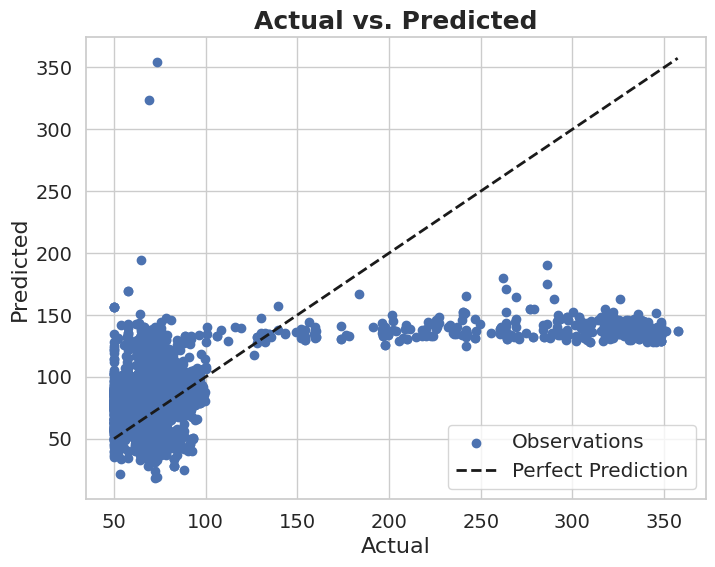

In [ ]:
import matplotlib.pyplot as plt

# Plotting the first output variable (CCME)
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred, color='b', label='Observations')
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual', fontsize=16)
plt.ylabel('Predicted', fontsize=16)
plt.title('Actual vs. Predicted', fontsize=18, fontweight='bold')
plt.legend(fontsize='large')

plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.show()

# **2. Lasso Regression**

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np

# Define the Lasso regression model with default parameters
lasso = Lasso(max_iter=10000)

# Fit the model
lasso.fit(X_train_reg, y_train_reg)

# Predict on test set
y_pred = lasso.predict(X_test_reg)

# Evaluation metrics
mae = mean_absolute_error(y_test_reg, y_pred)
mse = mean_squared_error(y_test_reg, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_reg, y_pred)
r2 = r2_score(y_test_reg, y_pred)

# Print results
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")
print(f"R2 Score: {r2}")

MAE: 25.297936998805316
MSE: 1882.6787567427746
RMSE: 43.3898462401375
MAPE: 0.27813600963948387
R2 Score: 0.27265711064248555


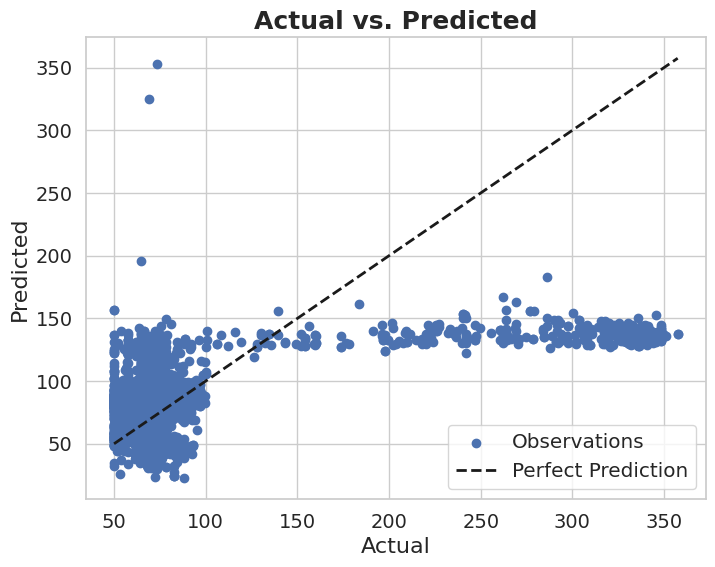

In [ ]:
# Plotting the first output variable (CCME)
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred, color='b', label='Observations')
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual', fontsize=16)
plt.ylabel('Predicted', fontsize=16)
plt.title('Actual vs. Predicted', fontsize=18, fontweight='bold')
plt.legend(fontsize='large')

plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.show()

# **3. Linear Regression**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np

# Define model with default parameters
lr = LinearRegression()

# Fit model
lr.fit(X_train_reg, y_train_reg)

# Predict
y_pred = lr.predict(X_test_reg)

# Metrics
mae = mean_absolute_error(y_test_reg, y_pred)
mse = mean_squared_error(y_test_reg, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_reg, y_pred)
r2 = r2_score(y_test_reg, y_pred)

# Output
print("Model Parameters:", lr.get_params())
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")
print(f"R2 Score: {r2}")

Model Parameters: {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}
MAE: 25.131823395939602
MSE: 1875.6908539465876
RMSE: 43.30924674877858
MAPE: 0.27614334662677004
R2 Score: 0.2753567753580536


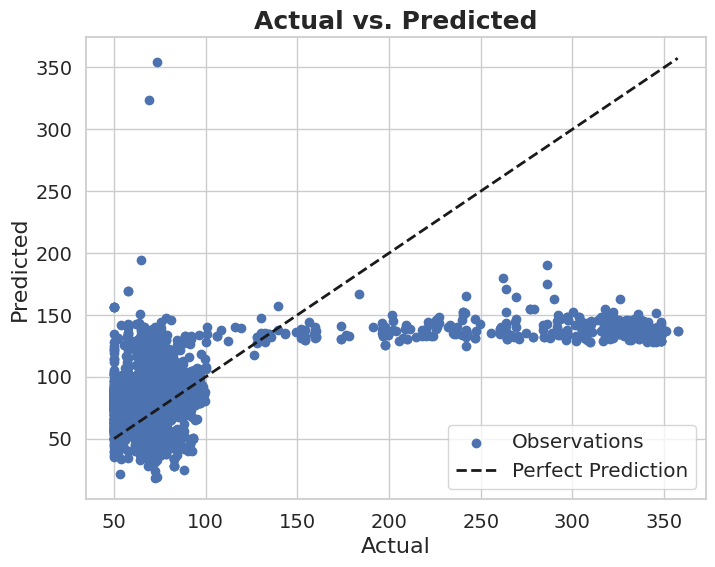

In [ ]:
# Plotting the first output variable (CCME)
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred, color='b', label='Observations')
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual', fontsize=16)
plt.ylabel('Predicted', fontsize=16)
plt.title('Actual vs. Predicted', fontsize=18, fontweight='bold')
plt.legend(fontsize='large')

plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.show()

# **4. Decision Tree Regressor**

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np

# Define the model with default parameters
dt = DecisionTreeRegressor(random_state=42)

# Fit model
dt.fit(X_train_reg, y_train_reg)

# Predict
y_pred = dt.predict(X_test_reg)

# Evaluation
mae = mean_absolute_error(y_test_reg, y_pred)
mse = mean_squared_error(y_test_reg, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_reg, y_pred)
r2 = r2_score(y_test_reg, y_pred)

# Output
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")
print(f"R2 Score: {r2}")

MAE: 0.03284218810512066
MSE: 0.08767347691306691
RMSE: 0.2960970734625165
MAPE: 0.0002591512065892176
R2 Score: 0.9999661287514986


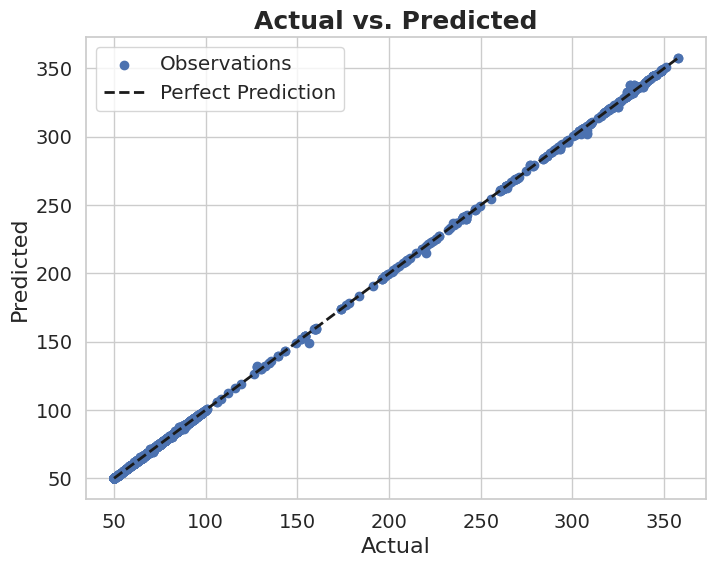

In [ ]:
# Plotting the first output variable (CCME)
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred, color='b', label='Observations')
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual', fontsize=16)
plt.ylabel('Predicted', fontsize=16)
plt.title('Actual vs. Predicted', fontsize=18, fontweight='bold')
plt.legend(fontsize='large')

plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.show()

# **5. Random Forest Regressor**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np

# Define the model with default parameters
rf = RandomForestRegressor(random_state=42)

# Fit the model
rf.fit(X_train_reg, y_train_reg)

# Predict
y_pred = rf.predict(X_test_reg)

# Evaluation
mae = mean_absolute_error(y_test_reg, y_pred)
mse = mean_squared_error(y_test_reg, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_reg, y_pred)
r2 = r2_score(y_test_reg, y_pred)

# Results
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")
print(f"R2 Score: {r2}")

MAE: 0.06200524261285445
MSE: 0.12165522887153606
RMSE: 0.3487910963191808
MAPE: 0.0005010259814130307
R2 Score: 0.9999530004439918


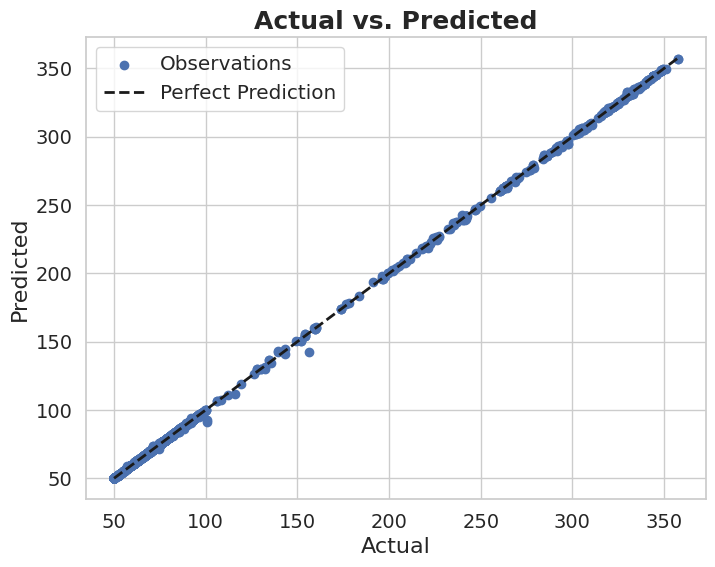

In [ ]:
# Plotting the first output variable (CCME)
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred, color='b', label='Observations')
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual', fontsize=16)
plt.ylabel('Predicted', fontsize=16)
plt.title('Actual vs. Predicted', fontsize=18, fontweight='bold')
plt.legend(fontsize='large')

plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.show()

# **6. XGB Regressor**

In [ ]:
# !pip install xgboost

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np

# Define and train the model with default parameters
xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_model.fit(X_train_reg, y_train_reg)

# Predict
y_pred = xgb_model.predict(X_test_reg)

# Evaluation
mae = mean_absolute_error(y_test_reg, y_pred)
mse = mean_squared_error(y_test_reg, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_reg, y_pred)
r2 = r2_score(y_test_reg, y_pred)

# Print results
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")
print(f"R2 Score: {r2}")

MAE: 0.18409049971533986
MSE: 0.8038735613561383
RMSE: 0.89658996277905
MAPE: 0.0017088162565807065
R2 Score: 0.9996894362797154


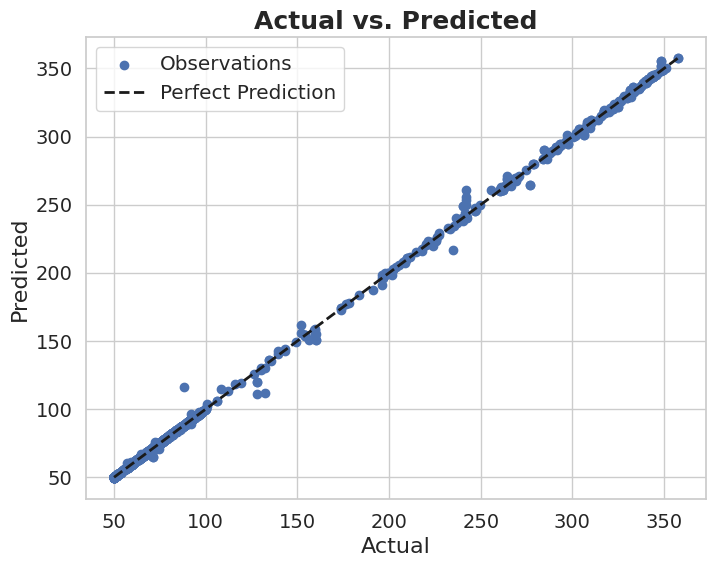

In [ ]:
# Plotting the first output variable (CCME)
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred, color='b', label='Observations')
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual', fontsize=16)
plt.ylabel('Predicted', fontsize=16)
plt.title('Actual vs. Predicted', fontsize=18, fontweight='bold')
plt.legend(fontsize='large')

plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.show()

# **7. Gradient Boosting Regressor**

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np

# Define the model with default parameters
gbr = GradientBoostingRegressor(random_state=42)

# Fit the model
gbr.fit(X_train_reg, y_train_reg)

# Predict
y_pred = gbr.predict(X_test_reg)

# Evaluation
mae = mean_absolute_error(y_test_reg, y_pred)
mse = mean_squared_error(y_test_reg, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_reg, y_pred)
r2 = r2_score(y_test_reg, y_pred)

# Output
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")
print(f"R2 Score: {r2}")

MAE: 0.28813795717971563
MSE: 0.3539002512484778
RMSE: 0.5948951598798546
MAPE: 0.0033392694303539167
R2 Score: 0.9998632762863204


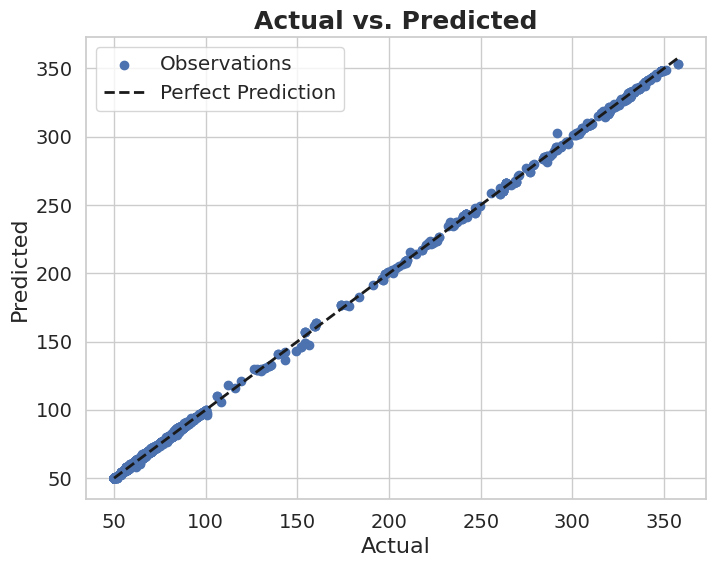

In [ ]:
# Plotting the first output variable (CCME)
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred, color='b', label='Observations')
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual', fontsize=16)
plt.ylabel('Predicted', fontsize=16)
plt.title('Actual vs. Predicted', fontsize=18, fontweight='bold')
plt.legend(fontsize='large')

plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.show()

# **8. LightGBM Regressor**

In [ ]:
# !pip install lightgbm


In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np

# Define LightGBM Regressor with default parameters
lgb_reg = lgb.LGBMRegressor(random_state=42)

# Fit model on training data
lgb_reg.fit(X_train_reg, y_train_reg)

# Predict on test data
y_pred = lgb_reg.predict(X_test_reg)

# Evaluation metrics
mae = mean_absolute_error(y_test_reg, y_pred)
mse = mean_squared_error(y_test_reg, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_reg, y_pred)
r2 = r2_score(y_test_reg, y_pred)

print("Best Parameters: Default parameters")
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")
print(f"R2 Score: {r2}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004646 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2497
[LightGBM] [Info] Number of data points in the train set: 23327, number of used features: 11
[LightGBM] [Info] Start training from score 82.641585
Best Parameters: Default parameters
MAE: 0.27385828782910326
MSE: 1.0949664878863534
RMSE: 1.0464064639930095
MAPE: 0.0024411962393210513
R2 Score: 0.9995769771735106


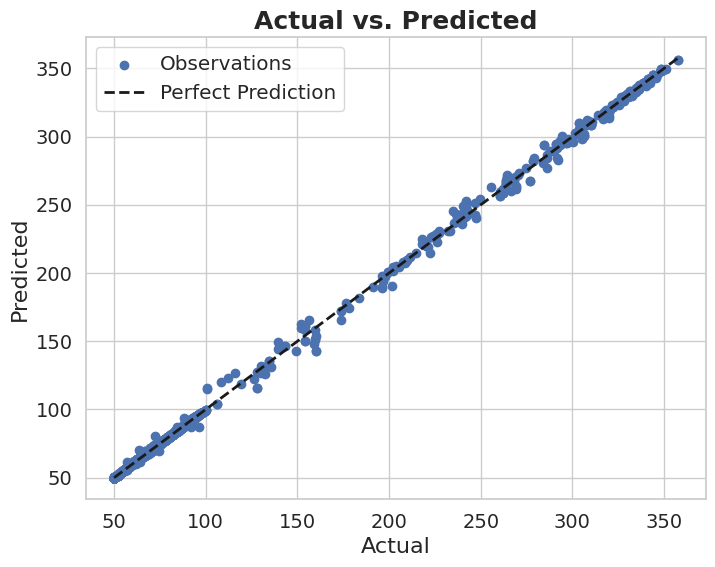

In [ ]:
# Plotting the first output variable (CCME)
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred, color='b', label='Observations')
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual', fontsize=16)
plt.ylabel('Predicted', fontsize=16)
plt.title('Actual vs. Predicted', fontsize=18, fontweight='bold')
plt.legend(fontsize='large')

plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.show()

# **10 KNeighbors Regressor**

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np

# Define the model with default parameters
knn = KNeighborsRegressor()

# Fit the model on training data
knn.fit(X_train_reg, y_train_reg)

# Predict on test set
y_pred = knn.predict(X_test_reg)

# Calculate metrics
mae = mean_absolute_error(y_test_reg, y_pred)
mse = mean_squared_error(y_test_reg, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_reg, y_pred)
r2 = r2_score(y_test_reg, y_pred)

# Print results
print("Using default KNeighborsRegressor parameters:")
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")
print(f"R2 Score: {r2}")

Using default KNeighborsRegressor parameters:
MAE: 8.881451969600208
MSE: 628.1814892597906
RMSE: 25.063549015648015
MAPE: 0.0937251489360487
R2 Score: 0.7573121076536649


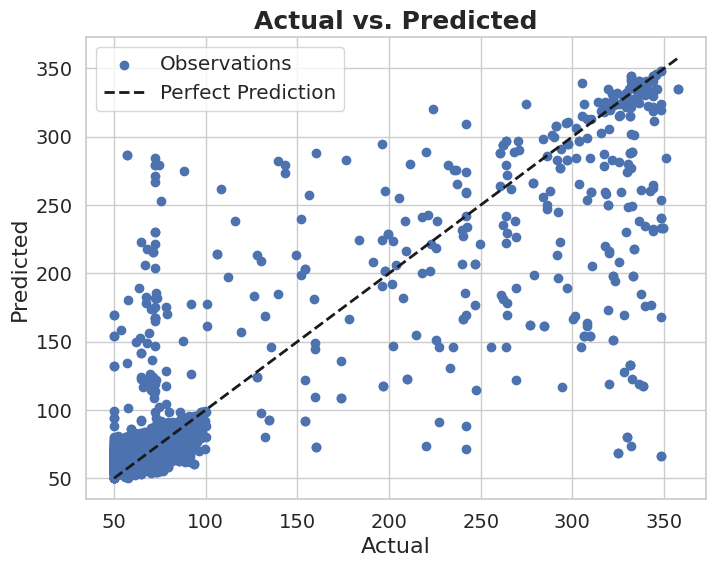

In [ ]:
# Plotting the first output variable (CCME)
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred, color='b', label='Observations')
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual', fontsize=16)
plt.ylabel('Predicted', fontsize=16)
plt.title('Actual vs. Predicted', fontsize=18, fontweight='bold')
plt.legend(fontsize='large')

plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.show()

# **12. MLP Regressor**

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np

# Define the model with default parameters (except max_iter and random_state)
mlp = MLPRegressor(max_iter=1000, random_state=42)

# Fit model
mlp.fit(X_train_reg, y_train_reg)

# Predict
y_pred = mlp.predict(X_test_reg)

# Evaluation
mae = mean_absolute_error(y_test_reg, y_pred)
mse = mean_squared_error(y_test_reg, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_reg, y_pred)
r2 = r2_score(y_test_reg, y_pred)

# Print results
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")
print(f"R2 Score: {r2}")

MAE: 5.310035412899032
MSE: 54.88636933603362
RMSE: 7.408533548282927
MAPE: 0.07173586210504304
R2 Score: 0.97879552721555


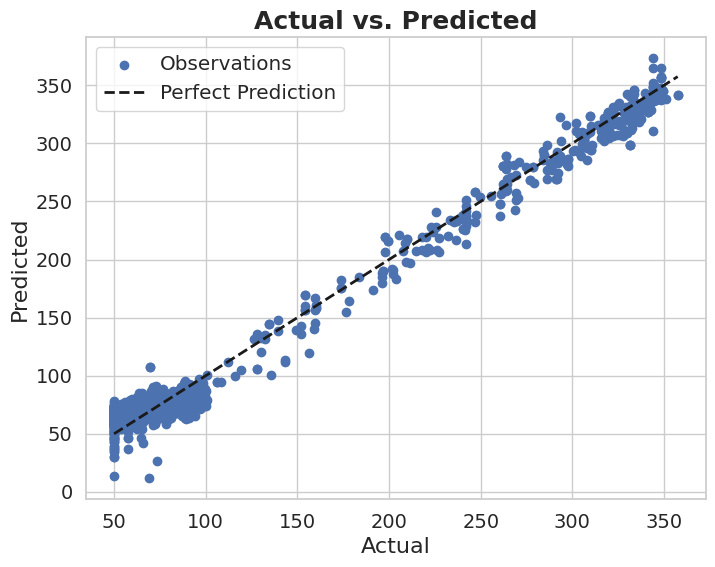

In [ ]:
# Plotting the first output variable
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred, color='b', label='Observations')
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual', fontsize=16)
plt.ylabel('Predicted', fontsize=16)
plt.title('Actual vs. Predicted', fontsize=18, fontweight='bold')
plt.legend(fontsize='large')

plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.show()

# **11. Support Vector Regression (SVR)**

In [ ]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np

# Define SVR model with default parameters
svr = SVR()

# Fit the model on training data
svr.fit(X_train_reg, y_train_reg)

# Predict on test data
y_pred = svr.predict(X_test_reg)

# Evaluation metrics
mae = mean_absolute_error(y_test_reg, y_pred)
mse = mean_squared_error(y_test_reg, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_reg, y_pred)
r2 = r2_score(y_test_reg, y_pred)

# Print results
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")
print(f"R2 Score: {r2}")

MAE: 16.552408938893684
MSE: 2608.456578304258
RMSE: 51.07305139018285
MAPE: 0.11641018291131859
R2 Score: -0.007735567011897704


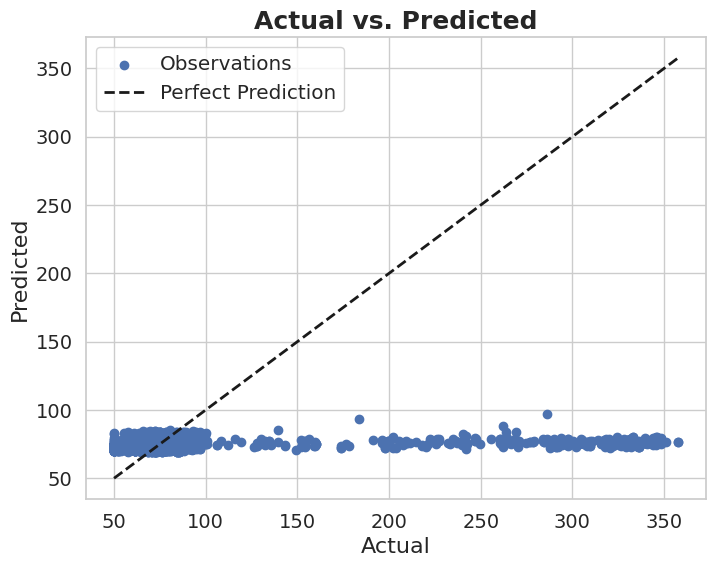

In [ ]:
# Plotting the first output variable
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred, color='b', label='Observations')
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual', fontsize=16)
plt.ylabel('Predicted', fontsize=16)
plt.title('Actual vs. Predicted', fontsize=18, fontweight='bold')
plt.legend(fontsize='large')

plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.show()